# Sistema de Clasificación de Imágenes — Perros vs Gatos
**Bootcamp de Data Science — 4Geeks Academy**

El objetivo es construir una Red Neuronal Convolucional, capaz de
distinguir automáticamente si una foto contiene un perro o un gato.

**¿Por qué es diferente a los modelos anteriores?**
- Los modelos anteriores (árbol, Random Forest, XGBoost) trabajaban con
  **tablas de números**.
- Este modelo trabaja con **imágenes** — que son matrices de píxeles.
- Para ello usamos **capas convolucionales (Conv2D)** que detectan bordes,
  formas y patrones visuales de forma automática.

**Arquitectura usada:** VGG16 — ganadora de la competencia ImageNet 2014.

> ⚠️ **Antes de empezar:** Descarga el dataset desde el link del ejercicio,
> descomprímelo y organiza las imágenes así:
> ```
> data/
> └── raw/
>     ├── dog/       ← fotos de perros
>     ├── cat/       ← fotos de gatos
>     └── test/      ← fotos para predecir
> ```


In [2]:
# Importamos las librerías necesarias
%pip install kaggle
!pip install tensorflow keras
import os
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing import image
import warnings
warnings.filterwarnings('ignore')
!pip install tensorflow
from tensorflow import keras

print("✅ Librerías importadas correctamente")
print(f"   TensorFlow/Keras listo para usar")


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


I0000 00:00:1776516468.967505    8661 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776516468.984648    8661 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776516470.617898    8661 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776516478.445283    8661 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✅ Librerías importadas correctamente
   TensorFlow/Keras listo para usar


In [3]:

# Verificamos desde dónde corre el notebook
print("Directorio actual:", os.getcwd())

# Buscamos la carpeta train
for root, dirs, files in os.walk("."):
    for f in files:
        if f == "cat.1.jpg":
            print("Imagen encontrada en:", root)
            break

Directorio actual: /workspaces/correaliesel138-a11y-intro-ml/src


In [4]:
import shutil

origen = "../data/raw/train_original/train"

os.makedirs("../data/raw/dog", exist_ok=True)
os.makedirs("../data/raw/cat", exist_ok=True)

for archivo in os.listdir(origen):
    if archivo.startswith("dog"):
        shutil.copy(os.path.join(origen, archivo), "../data/raw/dog/")
    elif archivo.startswith("cat"):
        shutil.copy(os.path.join(origen, archivo), "../data/raw/cat/")

print("✅ Imágenes organizadas correctamente")
print(f"Perros: {len(os.listdir('../data/raw/dog'))}")
print(f"Gatos:  {len(os.listdir('../data/raw/cat'))}")

✅ Imágenes organizadas correctamente
Perros: 12500
Gatos:  12500


## Paso 2: Visualización de las imágenes

### Primeras 9 fotos de perros

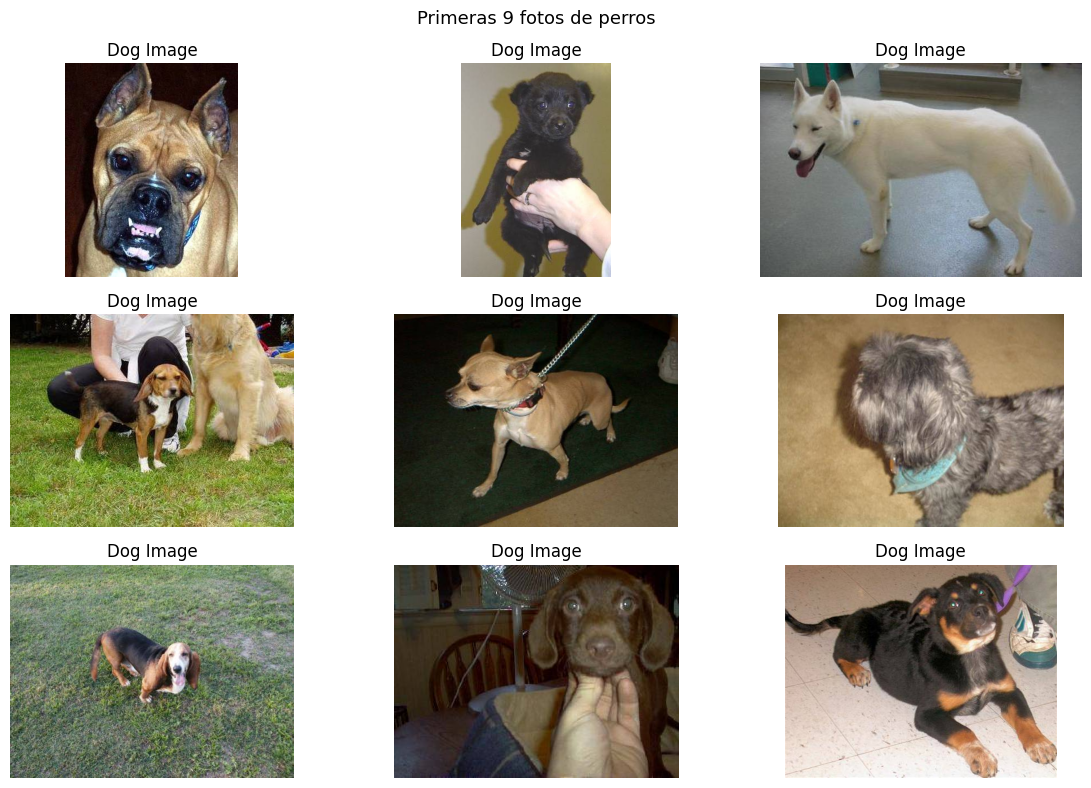

In [6]:
# Ruta donde están las imágenes
data_dir = "../data/raw"

# Carpeta de perros
dog_subfolder = os.path.join(data_dir, "dog")
dog_image_files = os.listdir(dog_subfolder)

# Cargamos las primeras 9 fotos de perros
dog_images = []
for i in range(9):
    img_path = os.path.join(dog_subfolder, dog_image_files[i])
    img = image.load_img(img_path)
    img_array = image.img_to_array(img)
    img_array /= 255.0  # Normalizamos los píxeles al rango [0, 1]
    dog_images.append(img_array)

# Mostramos las 9 fotos en una sola figura
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(dog_images[i])
    plt.title("Dog Image")
    plt.axis("off")

plt.suptitle("Primeras 9 fotos de perros", fontsize=13)
plt.tight_layout()
plt.show()


### Primeras 9 fotos de gatos

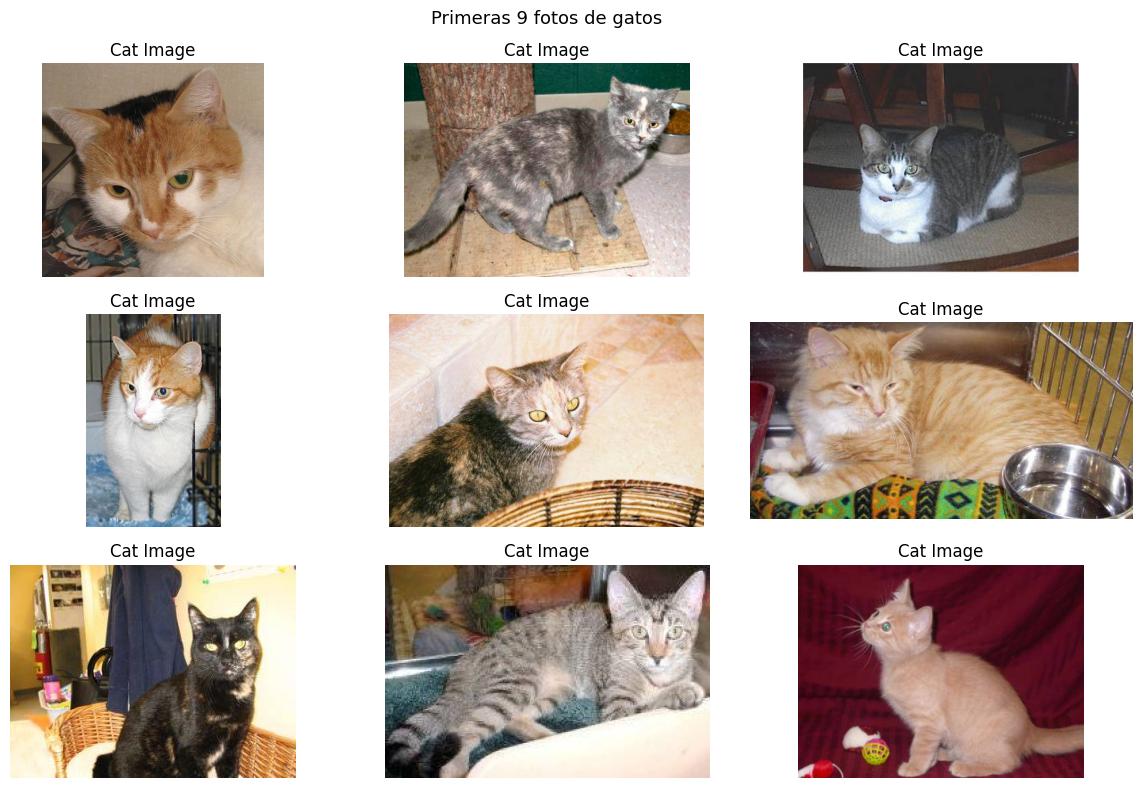

In [7]:
# Carpeta de gatos
cats_subfolder = os.path.join(data_dir, "cat")
cats_image_files = os.listdir(cats_subfolder)

# Cargamos las primeras 9 fotos de gatos
cats_images = []
for i in range(min(9, len(cats_image_files))):
    img_path = os.path.join(cats_subfolder, cats_image_files[i])
    img = image.load_img(img_path)
    img_array = image.img_to_array(img)
    img_array /= 255.0
    cats_images.append(img_array)

# Mostramos las 9 fotos en una sola figura
plt.figure(figsize=(12, 8))
for i in range(len(cats_images)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(cats_images[i])
    plt.title("Cat Image")
    plt.axis("off")

plt.suptitle("Primeras 9 fotos de gatos", fontsize=13)
plt.tight_layout()
plt.show()


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "../data/raw"

datagentrain = ImageDataGenerator(rescale=1./255)
datagentest  = ImageDataGenerator(rescale=1./255)

# Datos de entrenamiento
train_data = datagentrain.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    classes=["dog", "cat"],
    batch_size=16,
    class_mode="categorical"
)

# Para validación usamos los mismos datos de train
val_data = datagentrain.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    classes=["dog", "cat"],
    batch_size=16,
    class_mode="categorical"
)

print(f"Clases: {train_data.class_indices}")
print(f"Imágenes: {train_data.samples}")

Found 25000 images belonging to 2 classes.
Found 25000 images belonging to 2 classes.
Clases: {'dog': 0, 'cat': 1}
Imágenes: 25000


### Creación de los datasets de entrenamiento y test

## Paso 3: Construcción de la Red Neuronal mas ligero


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout

model = Sequential()

# Bloque 1 - más pequeño que VGG16
model.add(Conv2D(input_shape=(224, 224, 3), filters=32, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Bloque 2
model.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Bloque 3
model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Capas densas
model.add(Flatten())
model.add(Dense(units=256, activation="relu"))
model.add(Dropout(0.5))  # evita sobreajuste
model.add(Dense(units=2, activation="softmax"))

model.summary()

E0000 00:00:1776516587.286817    8661 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,784,130 (98.36 MB)

 Trainable params: 25,784,130 (98.36 MB)

 Non-trainable params: 0 (0.00 B)

### Compilación del modelo

> **Compilar** es decirle al modelo:
> - Cómo medir el error (`loss`)
> - Cómo corregirse (`optimizer`)
> - Qué métrica mostrar (`metrics`)


In [10]:
from keras.optimizers import Adam

model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

print("✅ Modelo compilado correctamente")


✅ Modelo compilado correctamente


### Entrenamiento inicial (1 época de prueba)

In [11]:
# Entrenamos 1 época para verificar que todo funciona
# (una época = el modelo ve todas las imágenes una vez)
print("Entrenando 1 época de prueba...")
model.fit(train_data, epochs=1, steps_per_epoch=100)


Entrenando 1 época de prueba...


I0000 00:00:1776516597.905262    8661 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


100/100 ━━━━━━━━━━━━━━━━━━━━ 101s 974ms/step - accuracy: 0.5094 - loss: 0.7792


In [12]:
from keras.callbacks import ModelCheckpoint, EarlyStopping
import os

os.makedirs("../models", exist_ok=True)

# Guarda el mejor modelo automáticamente
checkpoint = ModelCheckpoint(
    "../models/vgg16_1.h5",
    monitor="val_accuracy",    # vigila la accuracy en validación
    verbose=1,
    save_best_only=True,       # solo guarda si mejora
    save_weights_only=False,
    mode="auto"
)

# Para el entrenamiento si no mejora en 3 épocas seguidas
early = EarlyStopping(
    monitor="val_accuracy",
    patience=3,                # espera 3 épocas sin mejora antes de parar
    verbose=1,
    mode="auto"
)

# Entrenamos con los callbacks
hist = model.fit(
    train_data,
    steps_per_epoch=50,
    validation_data=val_data,
    validation_steps=3,
    epochs=3,
    callbacks=[checkpoint, early]
)


Epoch 1/3


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.5008 - loss: 0.6943
Epoch 1: val_accuracy improved from None to 0.60417, saving model to ../models/vgg16_1.h5



Epoch 1: finished saving model to ../models/vgg16_1.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 675ms/step - accuracy: 0.5163 - loss: 0.6913 - val_accuracy: 0.6042 - val_loss: 0.6836
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5495 - loss: 0.6884
Epoch 2: val_accuracy did not improve from 0.60417
50/50 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.5713 - loss: 0.6824 - val_accuracy: 0.6042 - val_loss: 0.6897
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5569 - loss: 0.6855
Epoch 3: val_accuracy improved from 0.60417 to 0.62500, saving model to ../models/vgg16_1.h5



Epoch 3: finished saving model to ../models/vgg16_1.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.5581 - loss: 0.6943 - val_accuracy: 0.6250 - val_loss: 0.6843


### Gráfica de accuracy y loss durante el entrenamiento

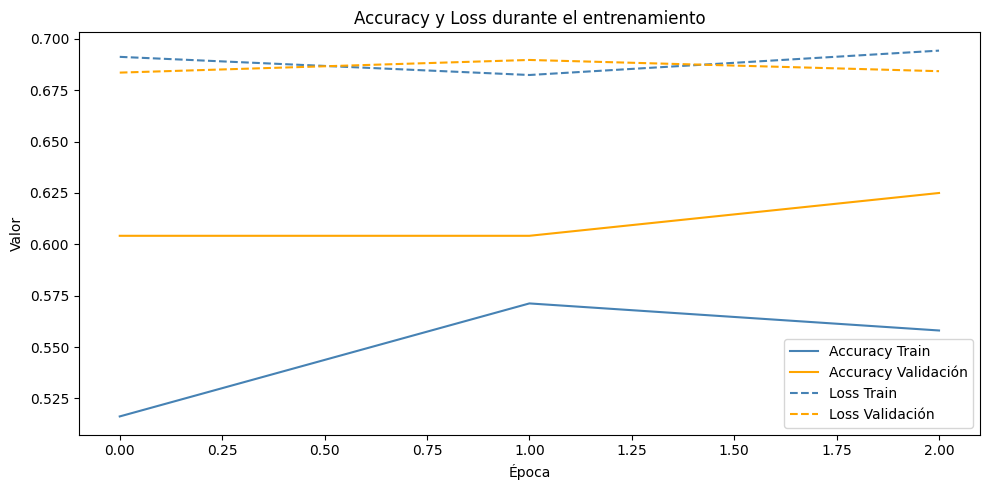

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(hist.history["accuracy"],     label="Accuracy Train",      color="steelblue")
plt.plot(hist.history["val_accuracy"], label="Accuracy Validación", color="orange")
plt.plot(hist.history["loss"],         label="Loss Train",          color="steelblue", linestyle="--")
plt.plot(hist.history["val_loss"],     label="Loss Validación",     color="orange",    linestyle="--")

plt.title("Accuracy y Loss durante el entrenamiento")
plt.ylabel("Valor")
plt.xlabel("Época")
plt.legend()
plt.tight_layout()
plt.show()


## Paso 5: Predicción con el modelo guardado

✅ Mejor modelo cargado correctamente


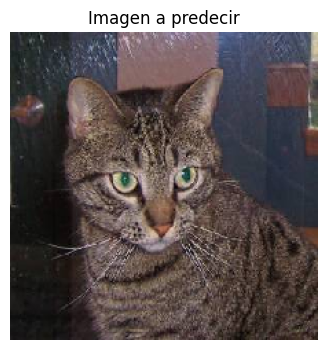

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Probabilidad perro: 49.4%
Probabilidad gato:  50.6%

🐶 Predicción: PERRO


In [15]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Cargamos el mejor modelo guardado
saved_model = load_model("../models/vgg16_1.h5")
print("✅ Mejor modelo cargado correctamente")

# Cargamos la imagen con el tamaño correcto 224x224
img_path = "../data/raw/test/9.jpg"
img = image.load_img(img_path, target_size=(224, 224))  # ← 224 no 200

# Mostramos la imagen
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Imagen a predecir")
plt.show()

# Preparamos la imagen para el modelo
img_array = np.asarray(img)
img_array = img_array / 255.0  # normalizamos
img_array = np.expand_dims(img_array, axis=0)

# Predecimos
output = saved_model.predict(img_array)
print(f"\nProbabilidad perro: {output[0][0]*100:.1f}%")
print(f"Probabilidad gato:  {output[0][1]*100:.1f}%")

if output[0][0] > output[0][1]:
    print("\n🐱 Predicción: GATO")
else:
    print("\n🐶 Predicción: PERRO")


### Guardado final del modelo

In [16]:
# El modelo ya se guardó automáticamente con ModelCheckpoint
# pero también lo guardamos manualmente como respaldo
saved_model.save("../models/vgg16_cats_dogs_final.h5")
print("✅ Modelo guardado en: ../models/vgg16_cats_dogs_final.h5")


✅ Modelo guardado en: ../models/vgg16_cats_dogs_final.h5
